#Post-processing & Data Harmonization

Cleaning & Refinement. Menghapus artefak, menambal data yang hilang, dan menyeragamkan format, untuk menghasilkan sinyal numerik yang bersih dan terstandarisasi.

In [ ]:
!pip install pandas numpy scipy

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os
from scipy import signal as sp_signal
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/dataset_ecg_rsab'
DATASET_PATH = os.path.join(BASE_DIR, 'output_data_digitizer')

METADATA_FILE = os.path.join(DATASET_PATH, 'digitization_metadata.csv')

OUTPUT_CLEAN = os.path.join(BASE_DIR, 'opentslm_ready')
os.makedirs(OUTPUT_CLEAN, exist_ok=True)

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/dataset_ecg_rsab/output_data_digitizer/'
METADATA_CLINICAL_PATH = '/content/drive/MyDrive/dataset_ecg_rsab/train/metadata_ecg_rsab.csv'

df_digit = pd.read_csv(os.path.join(DATASET_PATH, 'digitization_metadata.csv'))
df_clinical = pd.read_csv(METADATA_CLINICAL_PATH)

print("Kolom di digitization_metadata:", df_digit.columns.tolist())
print("Kolom di metadata_ecg_rsab:", df_clinical.columns.tolist())

Kolom di digitization_metadata: ['file_path', 'matching_cost', 'is_flipped', 'lead_layout']
Kolom di metadata_ecg_rsab: ['id,file_path,image,age,sex,heart_rate,indication,primary_label,arrhythmia_type,conduction_disorder,pacemaker,diagnosis,interpretation']


In [ ]:
# Ensure the filename column is created in df_digit before checking
import os

# Standardize filenames: keep them similar to the 'image' column in clinical data
# Clinical 'image' looks like 'ecg(1).jpg', so we create 'filename' as 'ecg(1).jpg' from 'file_path'
df_digit['filename'] = df_digit['file_path'].apply(lambda x: os.path.basename(x) + '.jpg' if not x.endswith('.jpg') else os.path.basename(x))

# Cek 5 contoh nama file dari kedua dataframe
print("Contoh 5 file dari Digitizer:", df_digit['filename'].head().tolist())
print("Contoh 5 file dari Clinical:", df_clinical['image'].head().tolist())

# Cek apakah ada irisan (intersection) sama sekali?
set_digit = set(df_digit['filename'].tolist())
set_clinic = set(df_clinical['image'].tolist())
irisan = set_digit.intersection(set_clinic)

print(f"\nJumlah data yang cocok: {len(irisan)}")
if len(irisan) == 0:
    print("WARNING: Tidak ada nama file yang sama persis!")
    print("Contoh file Digitizer (yang harus dicocokkan):", list(set_digit)[:3])
    print("Contoh file Clinical (yang ada di database):", list(set_clinic)[:3])

Contoh 5 file dari Digitizer: ['ecg(68).jpg', 'ecg(16).jpg', 'ecg(7).jpg', 'ecg(57).jpg', 'ecg(1).jpg']
Contoh 5 file dari Clinical: ['ecg(1).jpg', 'ecg(2).jpg', 'ecg(3).jpg', 'ecg(4).jpg', 'ecg(5).jpg']

Jumlah data yang cocok: 110


In [ ]:
# Load clinical metadata and split comma-separated columns
df_clinical = pd.read_csv('/content/drive/MyDrive/dataset_ecg_rsab/train/metadata_ecg_rsab.csv')
new_cols = df_clinical.columns[0].split(',')
df_clinical = df_clinical.iloc[:, 0].str.split(',', expand=True)
df_clinical.columns = new_cols
df_clinical.columns = df_clinical.columns.str.replace('\r', '').str.strip()

# Standardize df_digit filename to match df_clinical['image'] (e.g., 'ecg(1).jpg')
import os
df_digit['filename'] = df_digit['file_path'].apply(lambda x: os.path.basename(x) + '.jpg' if not x.endswith('.jpg') else os.path.basename(x))

# Merge using the consistent filename format
df_master = pd.merge(df_digit, df_clinical, left_on='filename', right_on='image', how='inner')
print(f"Berhasil merge! Total data: {len(df_master)}")
if len(df_master) > 0:
    print("Contoh data hasil merge:")
    print(df_master[['filename', 'id', 'age', 'sex']].head())

Berhasil merge! Total data: 110
Contoh data hasil merge:
      filename    id   age sex
0  ecg(68).jpg  0068   2.3   F
1  ecg(16).jpg  0016  4.83   M
2   ecg(7).jpg  0007  4.42   M
3  ecg(57).jpg  0057  15.8   F
4   ecg(1).jpg  0001  3.17   F


In [ ]:
# Lihat 5 ID pertama dari masing-masing dataset menggunakan kolom yang benar ('id')
print("5 ID dari Digitizer (df_digit):")
# Note: df_digit doesn't have 'id' yet, it's in df_master after merge
print(df_master['id'].head().tolist())

print("\n5 ID dari Clinical (df_clinical):")
print(df_clinical['id'].head().tolist())

# Cek tipe datanya
print(f"\nTipe data ID di Master: {type(df_master['id'].iloc[0])}")

5 ID dari Digitizer (df_digit):
['0068', '0016', '0007', '0057', '0001']

5 ID dari Clinical (df_clinical):
['0001', '0002', '0003', '0004', '0005']

Tipe data ID di Master: <class 'str'>


In [ ]:
def process_and_visualize(file_path, show_plot=False):
    raw_df = pd.read_csv(file_path)

    df_clean = raw_df.interpolate(method='linear', limit_direction='both').fillna(0)
    df_clean = df_clean.rolling(window=5, center=True).median().ffill().bfill()

    # Baseline & Resample
    df_clean = df_clean - df_clean.mean()
    target_samples = 1000
    resampled_data = sp_signal.resample(df_clean.values, target_samples, axis=0)
    final_df = pd.DataFrame(resampled_data, columns=raw_df.columns)

    if show_plot:
        # Plot 12 lead
        final_df.plot(subplots=True, layout=(4, 3), figsize=(15, 10), title="12-Lead ECG Data Harmonization")
        plt.tight_layout()
        plt.show()

    return final_df

In [ ]:
# Initialize metric columns in df_master
df_master['MSE'] = np.nan
df_master['Correlation'] = np.nan

def get_csv_filename(original_path):
    base_name = os.path.splitext(original_path)[0]
    return f"{base_name}_timeseries_canonical.csv"

print("Memproses seluruh dataset dan menghitung metrik...")
for index, row in df_master.iterrows():
    filename = get_csv_filename(row['file_path_x'])
    file_path = os.path.join(DATASET_PATH, filename)

    if os.path.exists(file_path):
        # 1. Load Raw
        raw_df = pd.read_csv(file_path)
        # 2. Process to Clean
        cleaned_df = process_and_visualize(file_path, show_plot=False)
        # 3. Calculate Metrics
        mse_val, corr_val = calculate_metrics(raw_df, cleaned_df)
        # 4. Save to df_master
        df_master.at[index, 'MSE'] = mse_val
        df_master.at[index, 'Correlation'] = corr_val
        # 5. Save .npy
        np.save(os.path.join(OUTPUT_CLEAN, filename.replace('.csv', '.npy')), cleaned_df.values)

print("Pemrosesan selesai. Metrik telah disimpan ke df_master.")
print(df_master[['filename', 'MSE', 'Correlation']].head())

Memproses seluruh dataset dan menghitung metrik...
Pemrosesan selesai. Metrik telah disimpan ke df_master.
      filename            MSE  Correlation
0  ecg(68).jpg  542740.004329     0.995808
1  ecg(16).jpg  647398.038357     0.998730
2   ecg(7).jpg    1531.607353     0.997173
3  ecg(57).jpg  317751.183575     0.998554
4   ecg(1).jpg  155395.030772     0.999252


In [ ]:
def calculate_metrics(raw_df, cleaned_df):
    mses = []
    corrs = []

    for i in range(raw_df.shape[1]):
        raw_lead = raw_df.values[:, i]
        clean_lead = cleaned_df.values[:, i]

        # If lengths differ, resample the CLEAN data to match RAW data length
        # This prevents NaN propagation that happens when resampling raw data with NaNs
        if len(raw_lead) != len(clean_lead):
            clean_lead = sp_signal.resample(clean_lead, len(raw_lead))

        mask = ~np.isnan(raw_lead)
        # Only process if lead has valid data and is not constant
        if np.any(mask) and np.nanstd(raw_lead) > 0:
            valid_raw = raw_lead[mask]
            valid_clean = clean_lead[mask]

            mse = np.mean((valid_raw - valid_clean)**2)
            mses.append(mse)

            c = np.corrcoef(valid_raw, valid_clean)[0, 1]
            if not np.isnan(c):
                corrs.append(c)

    avg_mse = np.mean(mses) if mses else np.nan
    avg_corr = np.mean(corrs) if corrs else 0.0

    return avg_mse, avg_corr

# Reload and verify
raw_df_last = pd.read_csv(file_path)
mse_val, corr_val = calculate_metrics(raw_df_last, cleaned_df)

print(f"Quality Metrics for {os.path.basename(file_path)} (Original Scale Analysis):")
print(f"Average MSE: {mse_val:.4f}")
print(f"Average Correlation: {corr_val:.4f}")

Quality Metrics for ecg(88)_timeseries_canonical.csv (Original Scale Analysis):
Average MSE: 254927.5533
Average Correlation: 0.9978


In [ ]:
# Cek data kosong (Null values)
# Corrected 'id_num' to 'id' based on df_master structure
columns_to_check = [col for col in ['id', 'diagnosis', 'primary_label'] if col in df_master.columns]
null_counts = df_master[columns_to_check].isnull().sum()
print("Data kosong:\n", null_counts)

# Cek distribusi diagnosis untuk memastikan kategori sudah benar
if 'primary_label' in df_master.columns:
    print("\nDistribusi Diagnosis:")
    print(df_master['primary_label'].value_counts())
else:
    print("\nKolom 'primary_label' tidak ditemukan di df_master.")

Data kosong:
 id               0
diagnosis        0
primary_label    0
dtype: int64

Distribusi Diagnosis:
primary_label
Normal Sinus Rhythm                                                         54
Normal sinus rhythm                                                         13
Normal Sinus Rhythm; Hypertrophy                                            11
Normal Sinus Rhythm; Atrial Abnormality/Enlargement                          4
Arrhythmia                                                                   3
Normal Sinus Rhythm; Hypertrophy; Atrial Abnormality/Enlargement             3
Normal Sinus Rhythm; Conduction Disorder                                     3
Normal Sinus Rhythm; Hypertrophy; Conduction Disorder                        2
Normal Sinus Rhythm; Gangguan Konduksi                                       2
None                                                                         1
Normal Sinus Rhythm; Arrhythmia                                              1
Normal EKG

Analisis Kualitas Data per Grup Diagnosis:
                                                             MSE  Correlation
primary_label                                                                
Normal sinus rhythm; Arrhythmia                     8.929412e+06     0.999698
Borderline normal ECG                               7.659409e+04     0.999529
Normal Sinus Rhythm; Conduction Disorder; Atria...  1.056678e+05     0.999433
Normal EKG                                          1.553950e+05     0.999252
Paced rhythm                                        3.445497e+03     0.999135
Arrhythmia                                          1.551268e+06     0.999063
Normal sinus rhythm; RV Hypertrophy; LV dilated...  2.408402e+05     0.998897
Normal sinus rhythm; Hypertrophy; Ischemic pattern  4.788011e+05     0.998776
Sinus Rhythm; Right Axis Deviation; Hypertrophy...  2.314467e+05     0.998725
Conduction disorder                                 3.849919e+06     0.998599
Normal Sinus Rhythm; 

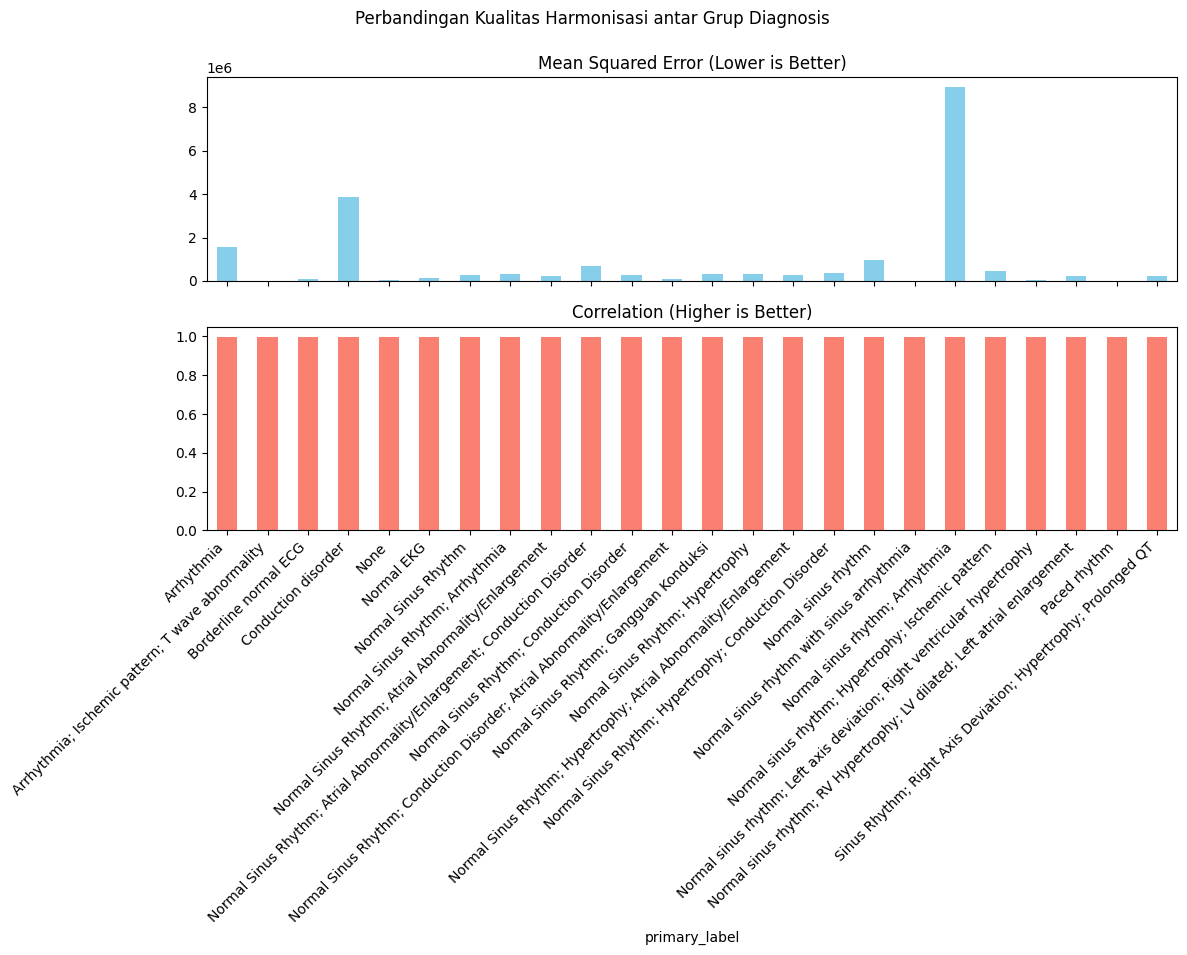

In [ ]:
# Analyze and visualize the quality metrics by diagnosis
metrics_comparison = df_master.groupby('primary_label')[['MSE', 'Correlation']].mean()

print("Analisis Kualitas Data per Grup Diagnosis:")
print(metrics_comparison.sort_values(by='Correlation', ascending=False))

# Visualisasi
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
metrics_comparison['MSE'].plot(kind='bar', ax=axes[0], title='Mean Squared Error (Lower is Better)', color='skyblue')
metrics_comparison['Correlation'].plot(kind='bar', ax=axes[1], title='Correlation (Higher is Better)', color='salmon')

plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Perbandingan Kualitas Harmonisasi antar Grup Diagnosis')
plt.show()

In [ ]:
def map_diagnosis(label):
    label = str(label).lower()
    if 'normal' in label: return 'Normal'
    if 'arrhythmia' in label or 'conduction' in label: return 'Arrhythmia'
    if 'hypertrophy' in label or 'enlargement' in label: return 'Structural'
    return 'Other'

df_master['new_label'] = df_master['primary_label'].apply(map_diagnosis)

print(df_master['new_label'].value_counts())

new_label
Normal        103
Arrhythmia      4
Other           2
Structural      1
Name: count, dtype: int64


In [ ]:
import pandas as pd
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Updated mapping to ensure enough samples per class for stratification
def map_diagnosis(label):
    label = str(label).lower()
    if 'normal' in label: return 'Normal'
    if 'arrhythmia' in label or 'conduction' in label: return 'Arrhythmia'
    return 'Abnormal/Other'

df_master['new_label'] = df_master['primary_label'].apply(map_diagnosis)
print("New Class Distribution:\n", df_master['new_label'].value_counts())

# Encode Label
le = LabelEncoder()
df_master['label_idx'] = le.fit_transform(df_master['new_label'])

# Split Dataset
# First split: Stratify is okay here because we have at least 3 samples per class
train_df, temp_df = train_test_split(df_master, test_size=0.3, stratify=df_master['label_idx'], random_state=42)

# Second split: Disable stratify here because temp_df likely contains classes with only 1 sample
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"\nSplit Sizes -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Calculate class weights for imbalance
class_counts = df_master['label_idx'].value_counts().sort_index()
total_samples = len(df_master)
class_weights = total_samples / (len(class_counts) * class_counts)
weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)

print("Class Weights for Loss Function:", weights_tensor)

New Class Distribution:
 new_label
Normal            103
Arrhythmia          4
Abnormal/Other      3
Name: count, dtype: int64

Split Sizes -> Train: 77, Val: 16, Test: 17
Class Weights for Loss Function: tensor([12.2222,  9.1667,  0.3560])


In [ ]:
# Simpan ke Google Drive
train_df.to_csv('/content/drive/MyDrive/dataset_ecg_rsab/train_data.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/dataset_ecg_rsab/val_data.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/dataset_ecg_rsab/test_data.csv', index=False)

# Simpan class weights untuk digunakan di Loss Function nanti
torch.save(weights_tensor, '/content/drive/MyDrive/dataset_ecg_rsab/class_weights.pt')

print(" Data Train, Val, Test, dan Class Weights berhasil disimpan!")

 Data Train, Val, Test, dan Class Weights berhasil disimpan!
